<a href="https://colab.research.google.com/github/yccccc12/DocStruct-VLM/blob/master/experiments/MinerU2_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Using Backend Transformer

In [ ]:
!pip install "mineru-vl-utils[transformers]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 116.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.6 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration
from PIL import Image
from mineru_vl_utils import MinerUClient
import base64
import io
import json
from PIL import Image, ImageDraw
from IPython.display import display, HTML

In [ ]:
model = Qwen2VLForConditionalGeneration.from_pretrained(
    "opendatalab/MinerU2.5-2509-1.2B",
    dtype="auto",
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(
    "opendatalab/MinerU2.5-2509-1.2B",
    use_fast=True
)

client = MinerUClient(backend="transformers",model=model,processor=processor)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.31G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/346 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/800 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

In [ ]:
image = Image.open("/content/Test1.png")
extracted_blocks = client.two_step_extract(image)

Predict: 100%|██████████| 6/6 [01:40<00:00, 16.79s/it]

[{'type': 'title', 'bbox': [0.013, 0.013, 0.202, 0.047], 'angle': 0, 'content': '3 Experiments'}, {'type': 'text', 'bbox': [0.012, 0.083, 0.986, 0.141], 'angle': 0, 'content': "In this section, we first introduce the overall model and compare it with the current state-of-the-art (SoTA) models. Then, we evaluate the model's performance across various sub-capabilities."}, {'type': 'title', 'bbox': [0.013, 0.177, 0.414, 0.208], 'angle': 0, 'content': '3.1 Comparison with the SOTA Models'}, {'type': 'table_caption', 'bbox': [0.219, 0.244, 0.776, 0.273], 'angle': 0, 'content': 'Table 3: Performance of Qwen2.5-VL and State-of-the-art.'}, {'type': 'table', 'bbox': [0.024, 0.296, 0.977, 0.799], 'angle': 0, 'content': '<table><tr><td>Datasets</td><td>Previous Open-source SoTA</td><td>Claude-3.5 Sonnet-0620</td><td>GPT-40 0513</td><td>InternVL2.5 78B</td><td>Qwen2-VL 72B</td><td>Qwen2.5-VL 72B</td><td>Qwen2.5-VL 7B</td><td>Qwen2.5-VL 3B</td></tr><tr><td colspan="9">College-level Problems</td></t

In [ ]:
extracted_blocks

[{'type': 'title',
  'bbox': [0.013, 0.013, 0.202, 0.047],
  'angle': 0,
  'content': '3 Experiments'},
 {'type': 'text',
  'bbox': [0.012, 0.083, 0.986, 0.141],
  'angle': 0,
  'content': "In this section, we first introduce the overall model and compare it with the current state-of-the-art (SoTA) models. Then, we evaluate the model's performance across various sub-capabilities."},
 {'type': 'title',
  'bbox': [0.013, 0.177, 0.414, 0.208],
  'angle': 0,
  'content': '3.1 Comparison with the SOTA Models'},
 {'type': 'table_caption',
  'bbox': [0.219, 0.244, 0.776, 0.273],
  'angle': 0,
  'content': 'Table 3: Performance of Qwen2.5-VL and State-of-the-art.'},
 {'type': 'table',
  'bbox': [0.024, 0.296, 0.977, 0.799],
  'angle': 0,
  'content': '<table><tr><td>Datasets</td><td>Previous Open-source SoTA</td><td>Claude-3.5 Sonnet-0620</td><td>GPT-40 0513</td><td>InternVL2.5 78B</td><td>Qwen2-VL 72B</td><td>Qwen2.5-VL 72B</td><td>Qwen2.5-VL 7B</td><td>Qwen2.5-VL 3B</td></tr><tr><td colspan=

In [ ]:
with open("output.json", "w", encoding="utf-8") as f:
    json.dump(extracted_blocks, f, indent=2, ensure_ascii=False)


In [ ]:
def display_extraction(image_path: str, layout_data: list):
    # 1. Define colors for different block types
    color_map = {
        "header": "#FF5733",  # Red-Orange
        "title": "#C70039",  # Dark Red
        "text": "#2E86C1",  # Blue
        "list": "#8E44AD",  # Purple
        "table": "#27AE60",  # Green
        "table_caption": "#16A085",  # Teal
        "figure": "#F39C12",  # Orange
        "default": "#34495E",  # Dark Grey
    }

    try:
        # 2. Load and process the image
        with Image.open(image_path) as img:
            img = img.convert("RGB")
            draw = ImageDraw.Draw(img)
            width, height = img.size

            # Construct the HTML content for the right pane simultaneously
            right_pane_html = ""

            for item in layout_data:
                item_type = item.get("type", "default")
                content = item.get("content")
                bbox = item.get("bbox")  # [x1, y1, x2, y2] normalized

                # --- Draw Bounding Box ---
                if bbox:
                    # Convert normalized coordinates (0-1) to pixel coordinates
                    x1, y1, x2, y2 = bbox
                    rect_coords = [x1 * width, y1 * height, x2 * width, y2 * height]

                    # Get color
                    color = color_map.get(item_type, color_map["default"])

                    # Draw rectangle (outline)
                    draw.rectangle(rect_coords, outline=color, width=3)

                    # Optional: Draw type label slightly above the box
                    # (Simple text drawing, might overlap on dense documents)
                    draw.text(
                        (rect_coords[0], rect_coords[1] - 10), item_type, fill=color
                    )

                # --- Build HTML Content ---
                if content:
                    # Clean escaped dollar signs for display
                    # clean_content = str(content).replace(r"$", "$")
                    clean_content = (
                        str(content)
                        .replace(r"\(", "")
                        .replace(r"\)", "")
                        .replace(r"\%", "%")
                    )

                    # clean_content = content

                    if item_type == "title":
                        right_pane_html += f"{clean_content}"
                    elif item_type == "header":
                        right_pane_html += (
                            f"{clean_content}"
                        )
                    elif item_type == "table":
                        # Tables usually come as raw HTML in these models
                        right_pane_html += f"{clean_content}"
                    elif item_type == "table_caption":
                        right_pane_html += f"{clean_content}"
                    else:
                        # Standard text
                        right_pane_html += f"{clean_content}"

            # 3. Convert processed PIL image to Base64 string
            buffered = io.BytesIO()
            img.save(buffered, format="PNG")
            img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
            image_uri = f"data:image/png;base64,{img_str}"

    except FileNotFoundError:
        print(f"Error: Image file not found at '{image_path}'")
        return
    except Exception as e:
        print(f"An error occurred: {e}")
        return

    # 4. Construct HTML Template
    html_template = f"""










        {right_pane_html}


    """

    display(HTML(html_template))

In [ ]:
display_extraction("/content/Test1.png", extracted_blocks)

In [ ]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

def visualize_mineru_results(image_path, layout_data):
    # Mapping MinerU types to specific colors
    color_map = {
        "title": "#C70039",          # Dark Red
        "text": "#2E86C1",           # Blue
        "table": "#27AE60",          # Green
        "table_caption": "#16A085",  # Teal
        "default": "#34495E"         # Dark Grey
    }

    try:
        # Open image
        img = Image.open(image_path).convert("RGB")
        draw = ImageDraw.Draw(img)
        width, height = img.size


        font = ImageFont.load_default()

        for item in layout_data:
            label = item.get("type", "default")
            bbox = item.get("bbox")
            color = color_map.get(label, color_map["default"])

            if bbox:
                x1, y1, x2, y2 = bbox

                # Convert normalized → pixel coordinates
                px_box = [
                    x1 * width,
                    y1 * height,
                    x2 * width,
                    y2 * height
                ]

                # Draw bounding box
                draw.rectangle(px_box, outline=color, width=4)

                # Draw label background
                text_width, text_height = draw.textbbox((0, 0), label, font=font)[2:]
                label_bg = [
                    px_box[0],
                    px_box[1] - text_height - 4,
                    px_box[0] + text_width + 6,
                    px_box[1]
                ]
                draw.rectangle(label_bg, fill=color)

                # Draw label text
                draw.text(
                    (px_box[0] + 3, px_box[1] - text_height - 2),
                    label,
                    fill="white",
                    font=font
                )

        # Display result
        plt.figure(figsize=(10, 12))
        plt.imshow(img)
        plt.axis("off")
        plt.title("Annotated Image with Predicted Labels")
        plt.show()

    except Exception as e:
        print(f"Error displaying image: {e}")

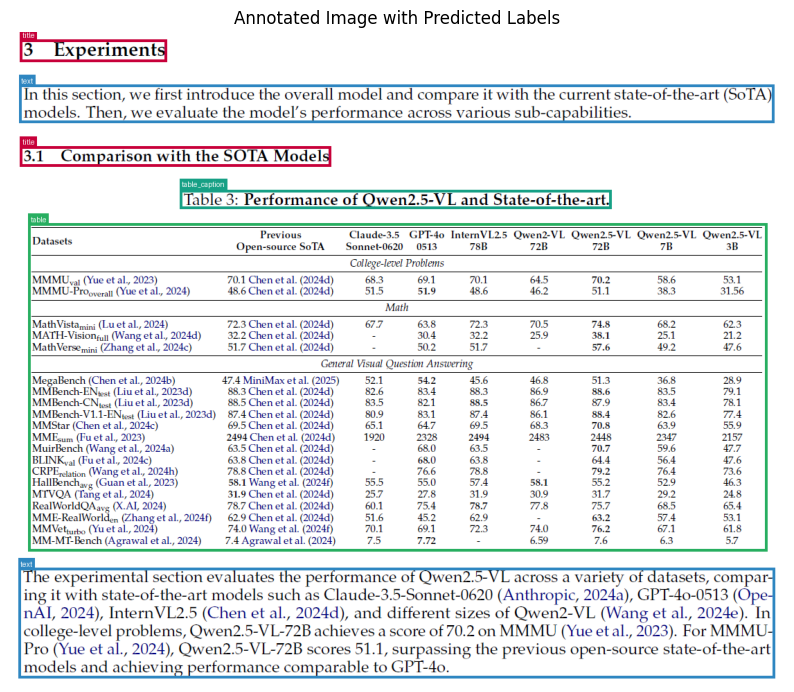

In [ ]:
visualize_mineru_results("/content/Test1.png", extracted_blocks)

## Using Command Line (mineru)

In [ ]:
!pip install --upgrade pip
!pip install uv
!uv pip install -U "mineru[all]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 44.5 MB/s  0:00:00
Using Python 3.12.12 environment at: /usr
Resolved 217 packages in 3.13s
Prepared 98 packages in 1m 38s
Uninstalled 39 packages in 1.17s
Installed 98 packages in 954ms
 + astor==0.8.1
 + av==16.1.0
 - beautifulsoup4==4.13.5
 + beautifulsoup4==4.14.3
 + blake3==1.0.8
 + boto3==1.42.59
 + botocore==1.42.59
 - cachetools==6.2.6
 + cachetools==7.0.1
 + cbor2==5.8.0
 - certifi==2026.1.4
 + certifi==2026.2.25
 + colorlog==6.10.1
 + compressed-tensors==0.11.0
 - cryptography==43.0.3
 + cryptography==46.0.5
 - cuda-pathfinder==1.3.5
 + cuda-pathfinder==1.4.0
 + depyf==0.19.0
 - dill==0.3.8
 + dill==0.4.1
 + diskcache==5.6.3
 + dnspython==2.8.0
 + doclayout-yolo==0.0.4
 + email-validator==2.3.0
 + fast-l

In [ ]:
!mineru --version

mineru, version 2.7.6


In [ ]:
!mineru -p "/content/Test1.png" -o "/content/output"

2026-03-01 13:46:10.289 | INFO     | mineru.utils.engine_utils:get_vlm_engine:32 - Using vllm-engine as the inference engine for VLM.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Fetching 14 files:   0% 0/14 [00:00<?, ?it/s]
README.md: 17.4kB [00:00, 42.7MB/s]

.gitattributes: 1.52kB [00:00, 10.0MB/s]
Fetching 14 files: 100% 14/14 [00:00<00:00, 62.57it/s]
2026-03-01 13:46:17.974 | INFO     | mineru.backend.vlm.utils:enable_custom_logits_processors:49 - compute_capability: 7.5 < 8.0, but vllm version: 0.11.0 >= 0.10.2, enable custom_logits_processors
INFO 03-01 13:46:19 [__init__.py:216] Automatically detected platform cuda.
E0000 00:00:1772372780.011718    8706 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting t

In [ ]:
!mineru -p "/content/UECM3993_MAY2025-1-3.pdf" -o "/content/output"

2026-03-01 13:52:34.064 | INFO     | mineru.utils.engine_utils:get_vlm_engine:32 - Using vllm-engine as the inference engine for VLM.
Fetching 14 files: 100% 14/14 [00:00<00:00, 147909.96it/s]
2026-03-01 13:52:36.779 | INFO     | mineru.backend.vlm.utils:enable_custom_logits_processors:49 - compute_capability: 7.5 < 8.0, but vllm version: 0.11.0 >= 0.10.2, enable custom_logits_processors
INFO 03-01 13:52:37 [__init__.py:216] Automatically detected platform cuda.
E0000 00:00:1772373159.419521   11271 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772373159.436611   11271 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772373159.465882   11271 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000